In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.get_cmap("Dark2").colors)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

# Put the repo's `src/` on sys.path so `quantproteomicssimbox` imports even without an editable
# install. This notebook lives in src/quantproteomicssimbox/, so its parent ("..") is `src/`.
src_path = os.path.abspath("..")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from quantproteomicssimbox import protgen, experiment
from quantproteomicssimbox.methods import intensity_method, stoichiometry_method
from quantproteomicssimbox.sweep import run_sweep

C:\Users\Peter\AppData\Local\Temp\ipykernel_5880\1706634584.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.get_cmap("Dark2").colors)


## Paper Explored Parameters
========================
 - Missingness: 0, 25, 50%
 - Number of Proteins: 5, 10
 - Total Abundance Per Protein: 100, 250
 - Length Proteins: 100, 200
 - Variance Level: 0, 1, 9
 - Incomplete Digestion Rate: 0, 25, 50%

The first figure compares the two quantification approaches per miscleavage model: **intensity**
roll-up (log2; mean / median / sum) vs **stoichiometry** roll-up (per-site modified fraction;
`fraction` and `logit`). Stoichiometry needs the spanning denominator, exact only under
**position-aware** observation, so everything below runs with `position_aware=True`.

In [2]:
missingness = 0
number_of_proteins = 10
total_abundance_per_protein = 250
length_proteins = 200
variance_level = 1
incomplete_digestion_rate = 0.5

In [3]:
miscleavage_models = ["global", "bernoulli"]
intensity_aggs = ["mean", "median", "sum"]
stoich_methods = ["fraction", "logit"]
n_repeats = 10

labels = [f"log2\n{a}" for a in intensity_aggs] + [f"stoich\n{m}" for m in stoich_methods]
rmses = {}  # {(model, label): [rmse per repeat]}

for model in miscleavage_models:
    exp = experiment.Experiment(
        n_proteins=number_of_proteins, protein_length=length_proteins, n_subjects=25,
        abundance=total_abundance_per_protein, miscleavage_rate=incomplete_digestion_rate,
        miscleavage_model=model, var_subject=variance_level, var_site=variance_level,
        missingness=missingness, position_aware=True,
    )
    rows = {lab: [] for lab in labels}
    for _ in range(n_repeats):
        exp.build()
        exp.observe()
        for a in intensity_aggs:
            rows[f"log2\n{a}"].append(exp.score(intensity_method(aggregation=a, space="log2")))
        for m in stoich_methods:
            rows[f"stoich\n{m}"].append(exp.score(stoichiometry_method(m)))
    for lab in labels:
        rmses[(model, lab)] = np.array(rows[lab])

rmses

{('global',
  'log2\nmean'): array([1.23931349, 1.0330607 , 0.96014636, 1.16506723, 0.97994641,
        1.22085225, 1.14303729, 1.05954253, 0.94965841, 1.47150918]),
 ('global',
  'log2\nmedian'): array([1.3097322 , 1.15303348, 1.11189215, 1.32941614, 1.16122492,
        1.26144137, 1.27083509, 1.21106935, 1.10139721, 1.64966271]),
 ('global',
  'log2\nsum'): array([10.57218734, 11.3514633 , 10.60687747,  9.77278531, 10.48376742,
        12.57940588, 10.39489254, 11.91046656, 11.53090643, 10.85134625]),
 ('global',
  'stoich\nfraction'): array([0.47406048, 0.4577046 , 0.44097952, 0.35971298, 0.36211613,
        0.5063012 , 0.40310024, 0.46179678, 0.35728214, 0.4345837 ]),
 ('global',
  'stoich\nlogit'): array([0.34675471, 0.22320976, 0.29250203, 0.20062913, 0.21184825,
        0.24575503, 0.24906506, 0.28616256, 0.19071014, 0.24924225]),
 ('bernoulli',
  'log2\nmean'): array([0.80422122, 0.89419606, 0.86454101, 1.16221118, 0.81786555,
        0.86986841, 1.06484236, 0.98349497, 1.06770

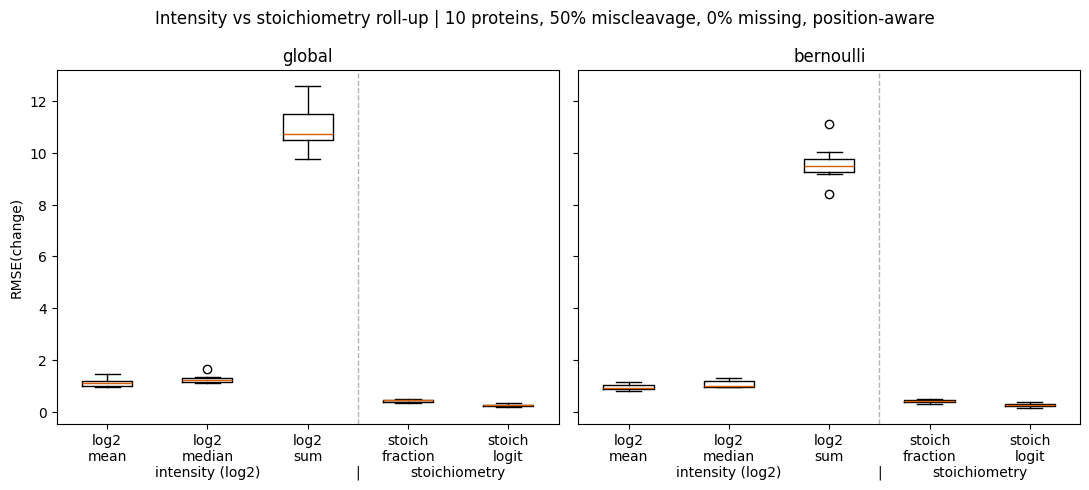

In [4]:
fig, axes = plt.subplots(1, len(miscleavage_models), figsize=(11, 5), sharey=True, squeeze=False)
yscale = "linear"
splitline = len(intensity_aggs) + 0.5
intensity_xlabel = len(intensity_aggs) / 2 + 0.5
stoich_xlabel = (len(intensity_aggs + stoich_methods) + len(intensity_aggs)) / 2 + 0.5
xlabel_yoff = -2.5

for c, model in enumerate(miscleavage_models):
    ax = axes[0][c]
    ax.boxplot([rmses[(model, lab)] for lab in labels], tick_labels=labels)
    ax.set_yscale(yscale)
    ax.axvline(len(intensity_aggs) + 0.5, color="0.7", ls="--", lw=1)
    ax.set_title(model)
    ax.text(intensity_xlabel, xlabel_yoff, "intensity (log2)", ha='center')
    ax.text(splitline, xlabel_yoff, "|", ha='center')
    ax.text(stoich_xlabel, xlabel_yoff, "stoichiometry", ha='center')
    

axes[0][0].set_ylabel("RMSE(change)" + f" [{yscale} scale]" * (yscale!="linear"))
fig.suptitle(
    f"Intensity vs stoichiometry roll-up | {number_of_proteins} proteins, "
    f"{int(incomplete_digestion_rate * 100)}% miscleavage, {int(missingness * 100)}% missing, position-aware"
)
fig.tight_layout()
plt.show()

## Aggregation-strategy investigations

Sweeps of the roll-up / aggregation strategies, scored as **mean RMSE** of the estimated vs true
per-site change. Compared: intensity (log2 median) vs the stoichiometry roll-up — **pooled**
(fraction / logit) and **per-peptide-span** (mean / median of per-span fractions). All position-aware.

In [5]:
# Methods to compare across the sweeps (kept to ~5 lines for readable plots).
METHODS = {
    "int median (log2)": lambda e: e.score(intensity_method(aggregation="median", space="log2")),
    "pooled (frac)": lambda e: e.score(stoichiometry_method("fraction")),
    "pooled (logit)": lambda e: e.score(stoichiometry_method("logit")),
    "pep-mean (frac)": lambda e: e.score(stoichiometry_method("peptide_mean")),
    "pep-median (frac)": lambda e: e.score(stoichiometry_method("peptide_median")),
}

# Fixed backdrop for the sweeps (kept small so the notebook runs in a couple of minutes).
BASE = dict(
    n_proteins=5, protein_length=120, n_subjects=12, abundance=200,
    miscleavage_rate=0.3, miscleavage_model="global",
    var_subject=1.0, var_site=1.0, var_species=0.0, missingness=0.0, position_aware=True,
)
N_REPEATS = 5


def mean_rmse(methods, base, n_repeats=N_REPEATS, seed0=0):
    """Mean RMSE per method over `n_repeats` fresh Experiments built from `base`."""
    acc = {lab: [] for lab in methods}
    for rep in range(n_repeats):
        exp = experiment.Experiment(rng=np.random.default_rng(seed0 + rep), **base)
        exp.build()
        exp.observe()
        for lab, fn in methods.items():
            acc[lab].append(fn(exp))
    return {lab: float(np.mean(v)) for lab, v in acc.items()}


def sweep(values, vary, base=BASE, methods=METHODS, n_repeats=N_REPEATS, seed0=0):
    """Mean RMSE per method as one Experiment kwarg (`vary`) ranges over `values`."""
    out = {lab: [] for lab in methods}
    for v in values:
        res = mean_rmse(methods, {**base, vary: v}, n_repeats, seed0)
        for lab in methods:
            out[lab].append(res[lab])
    return out


def plot_sweep(ax, values, results, xlabel, logy=True):
    for lab, ys in results.items():
        ax.plot(values, ys, marker="o", label=lab)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("mean RMSE(change)")

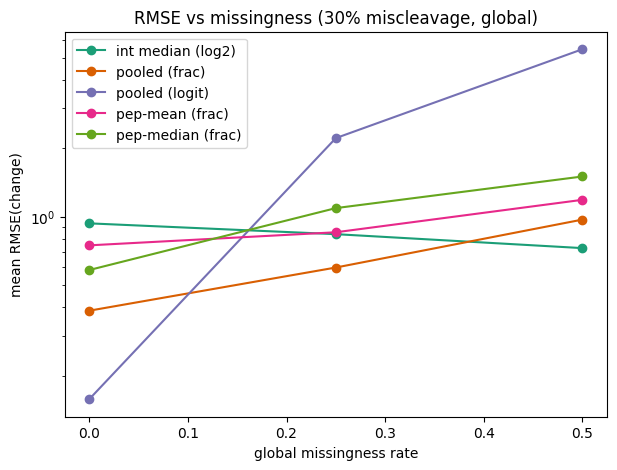

In [6]:
# 1) Missingness — how robust is each aggregation strategy as observations drop out (MNAR)?
missing = [0.0, 0.25, 0.5]
res = sweep(missing, "missingness")
fig, ax = plt.subplots(figsize=(7, 5))
plot_sweep(ax, missing, res, "global missingness rate")
ax.set_title("RMSE vs missingness (30% miscleavage, global)")
ax.legend()
plt.show()

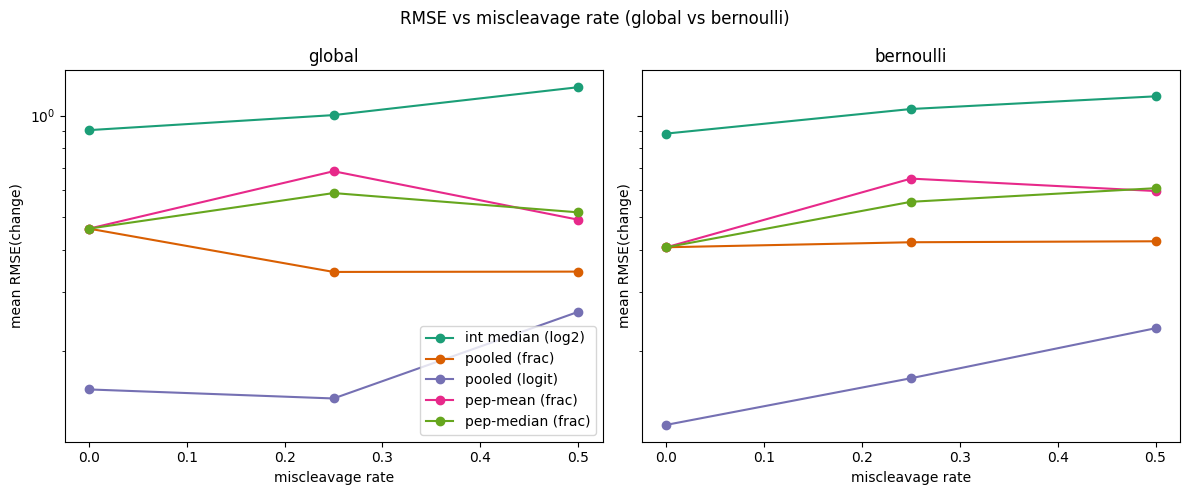

In [7]:
# 2) Digestion rate, global vs bernoulli — more miscleavage fragments each site into more spans.
rates = [0.0, 0.25, 0.5]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, model in zip(axes, ["global", "bernoulli"]):
    res = sweep(rates, "miscleavage_rate", base={**BASE, "miscleavage_model": model})
    plot_sweep(ax, rates, res, "miscleavage rate")
    ax.set_title(model)
axes[0].legend()
fig.suptitle("RMSE vs miscleavage rate (global vs bernoulli)")
fig.tight_layout()
plt.show()

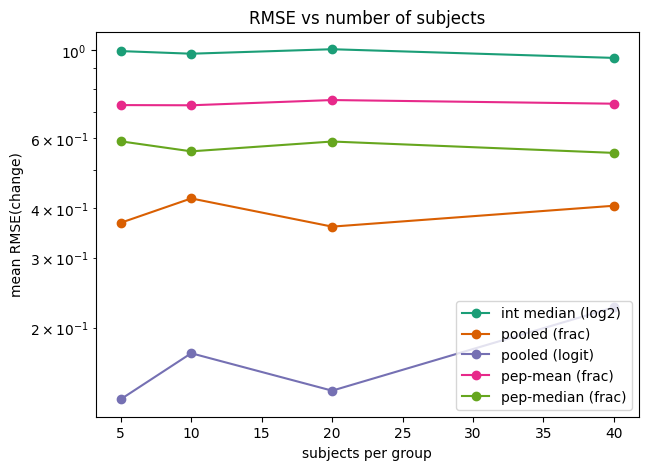

In [8]:
# 3) Subjects per group — more replicates average out subject/site noise.
subjects = [5, 10, 20, 40]
res = sweep(subjects, "n_subjects")
fig, ax = plt.subplots(figsize=(7, 5))
plot_sweep(ax, subjects, res, "subjects per group")
ax.set_title("RMSE vs number of subjects")
ax.legend()
plt.show()

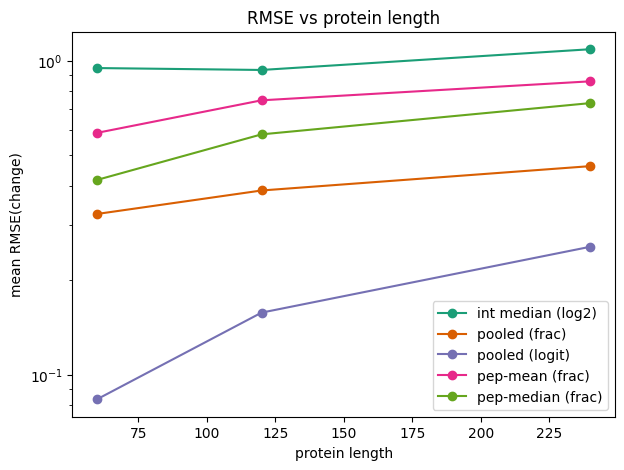

In [9]:
# 4) Protein length — longer proteins have more sites and (tryptic) peptides per site.
lengths = [60, 120, 240]
res = sweep(lengths, "protein_length")
fig, ax = plt.subplots(figsize=(7, 5))
plot_sweep(ax, lengths, res, "protein length")
ax.set_title("RMSE vs protein length")
ax.legend()
plt.show()

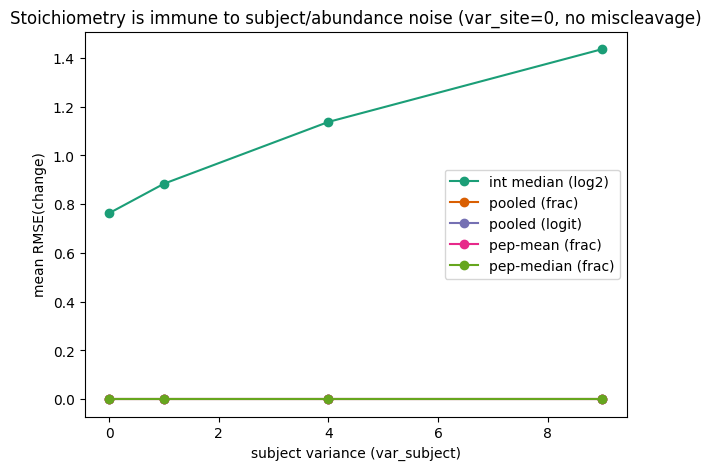

In [10]:
# 5) Insight: stoichiometry cancels the subject (abundance) effect. With var_site=0 and no
# miscleavage, the subject effect scales a sample's peptides equally -> cancels in every fraction, so
# stoichiometry RMSE stays ~0 as subject variance grows, while the intensity RMSE climbs.
variances = [0.0, 1.0, 4.0, 9.0]
res = sweep(variances, "var_subject", base={**BASE, "var_site": 0.0, "miscleavage_rate": 0.0})
fig, ax = plt.subplots(figsize=(7, 5))
plot_sweep(ax, variances, res, "subject variance (var_subject)", logy=False)
ax.set_title("Stoichiometry is immune to subject/abundance noise (var_site=0, no miscleavage)")
ax.legend()
plt.show()

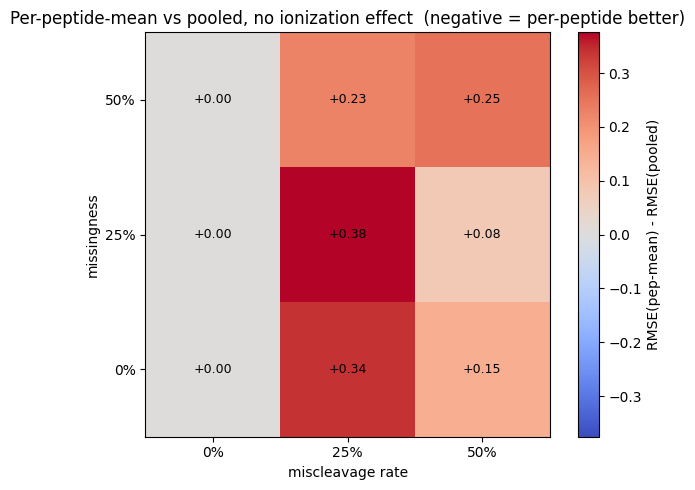

In [11]:
# 6) Insight: where does per-peptide-mean beat the pooled ratio? Heatmap of mean
# (RMSE pep-mean - RMSE pooled) over missingness x miscleavage (no per-species abundance effect yet).
miss_ax = [0.0, 0.25, 0.5]
mc_ax = [0.0, 0.25, 0.5]
diff = np.zeros((len(miss_ax), len(mc_ax)))
for i, m in enumerate(miss_ax):
    for j, c in enumerate(mc_ax):
        vals = mean_rmse(
            {"pool": lambda e: e.score(stoichiometry_method("fraction")),
             "pep": lambda e: e.score(stoichiometry_method("peptide_mean"))},
            {**BASE, "missingness": m, "miscleavage_rate": c},
        )
        diff[i, j] = vals["pep"] - vals["pool"]

fig, ax = plt.subplots(figsize=(6.5, 5))
vmax = np.abs(diff).max()
im = ax.imshow(diff, cmap="coolwarm", vmin=-vmax, vmax=vmax, origin="lower")
ax.set_xticks(range(len(mc_ax)), [f"{c:.0%}" for c in mc_ax])
ax.set_yticks(range(len(miss_ax)), [f"{m:.0%}" for m in miss_ax])
ax.set_xlabel("miscleavage rate")
ax.set_ylabel("missingness")
for i in range(len(miss_ax)):
    for j in range(len(mc_ax)):
        ax.text(j, i, f"{diff[i, j]:+.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, label="RMSE(pep-mean) - RMSE(pooled)")
ax.set_title("Per-peptide-mean vs pooled, no ionization effect  (negative = per-peptide better)")
fig.tight_layout()
plt.show()

### Ionization efficiency & position ambiguity

Two model extensions exercised below: a per-peptide-species ionization efficiency (`var_species`,
a fixed log2 factor per peptide backbone) that creates **real between-span abundance differences**,
and forced **repeated peptides** (`repeat_units`) that bottom-up MS cannot localize without
position-aware grouping.

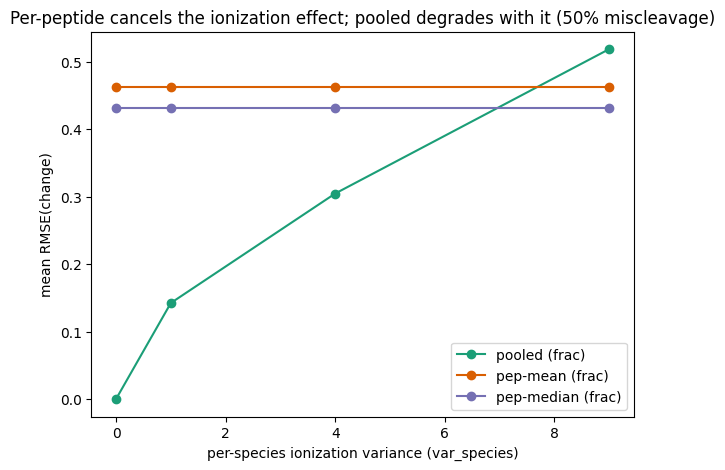

In [12]:
# 7) Ionization payoff: per-peptide fractions are INVARIANT to per-species ionization efficiency
# (it cancels in each span's mod/total ratio), while the pooled ratio is abundance-weighted and gets
# biased. Isolating it (var_subject=var_site=0, 50% miscleavage): pooled starts exact but degrades as
# var_species grows, crossing the flat per-peptide floor -> per-peptide wins once the effect is large.
methods_ion = {
    "pooled (frac)": lambda e: e.score(stoichiometry_method("fraction")),
    "pep-mean (frac)": lambda e: e.score(stoichiometry_method("peptide_mean")),
    "pep-median (frac)": lambda e: e.score(stoichiometry_method("peptide_median")),
}
species_var = [0.0, 1.0, 4.0, 9.0]
res = sweep(species_var, "var_species",
            base={**BASE, "var_subject": 0.0, "var_site": 0.0, "miscleavage_rate": 0.5},
            methods=methods_ion)
fig, ax = plt.subplots(figsize=(7, 5))
plot_sweep(ax, species_var, res, "per-species ionization variance (var_species)", logy=False)
ax.set_title("Per-peptide cancels the ionization effect; pooled degrades with it (50% miscleavage)")
ax.legend()
plt.show()

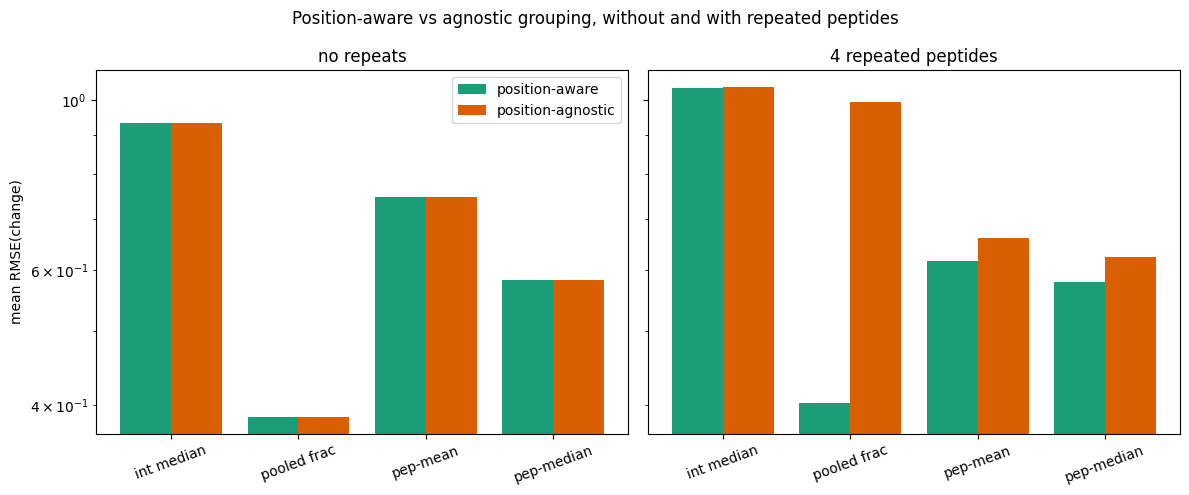

In [13]:
# 8) Position ambiguity: repeated peptides (same sequence at several loci) merge under
# position-AGNOSTIC grouping, mis-attributing the other loci's signal -> bias. Compare aware vs
# agnostic, without and with forced repeats, per method.
methods_rep = {
    "int median": lambda e: e.score(intensity_method(aggregation="median", space="log2")),
    "pooled frac": lambda e: e.score(stoichiometry_method("fraction")),
    "pep-mean": lambda e: e.score(stoichiometry_method("peptide_mean")),
    "pep-median": lambda e: e.score(stoichiometry_method("peptide_median")),
}
labels_rep = list(methods_rep)
x = np.arange(len(labels_rep))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (title, reps) in zip(axes, [("no repeats", 0), ("4 repeated peptides", 4)]):
    for k, aware in enumerate([True, False]):
        vals = mean_rmse(methods_rep, {**BASE, "repeat_units": reps, "position_aware": aware})
        ax.bar(x + (k - 0.5) * 0.4, [vals[l] for l in labels_rep], width=0.4,
               label="position-aware" if aware else "position-agnostic")
    ax.set_xticks(x, labels_rep, rotation=20)
    ax.set_yscale("log")
    ax.set_title(title)
axes[0].set_ylabel("mean RMSE(change)")
axes[0].legend()
fig.suptitle("Position-aware vs agnostic grouping, without and with repeated peptides")
fig.tight_layout()
plt.show()

### C1 — position-aware vs agnostic denominator bias

Bottom-up MS can't distinguish identical peptide sequences at different loci. Under **position-agnostic**
grouping they merge, so a shared peptide's intensity is mis-attributed across the loci it spans — biasing
the stoichiometry **denominator**. The bias grows with the density of repeated peptides (`repeat_units`).
Below (via `sweep.run_sweep`): stoichiometry RMSE vs repeat density, position-aware vs agnostic.

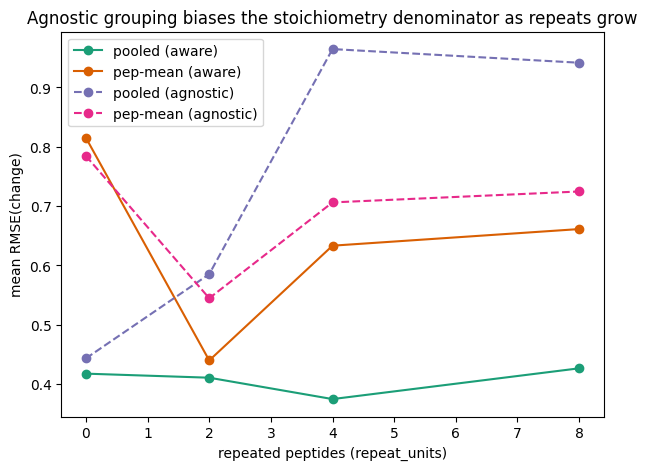

In [14]:
repeats = [0, 2, 4, 8]
c1_base = dict(n_proteins=5, protein_length=160, n_subjects=12, abundance=200,
               miscleavage_rate=0.3, var_subject=1.0, var_site=1.0, missingness=0.0)
c1_methods = {"pooled": stoichiometry_method("fraction"), "pep-mean": stoichiometry_method("peptide_mean")}
c1 = run_sweep({"repeat_units": repeats, "position_aware": [True, False]},
               c1_methods, n_replicates=4, base=c1_base)

curves = {}
for r in c1:
    curves.setdefault((r.method, r.params["position_aware"]), {})[r.params["repeat_units"]] = r.rmse_mean

fig, ax = plt.subplots(figsize=(7, 5))
for (method, aware), pts in curves.items():
    ax.plot(repeats, [pts[k] for k in repeats], marker="o", ls="-" if aware else "--",
            label=f"{method} ({'aware' if aware else 'agnostic'})")
ax.set_xlabel("repeated peptides (repeat_units)")
ax.set_ylabel("mean RMSE(change)")
ax.set_title("Agnostic grouping biases the stoichiometry denominator as repeats grow")
ax.legend()
plt.show()

### C2 — per-peptide win region, and the within-span efficiency question

Per-peptide-mean cancels the per-**species** ionization effect (`var_species`, a *between-span* abundance
difference) and the per-**subject** effect, but NOT the per-**site** effect (`var_site` = alpha, the
*within-span* mod-vs-unmod efficiency). So it wins where between-span abundance dominates. Heatmaps of
(RMSE pep-mean − RMSE pooled) over missingness × miscleavage, at two ionization levels:

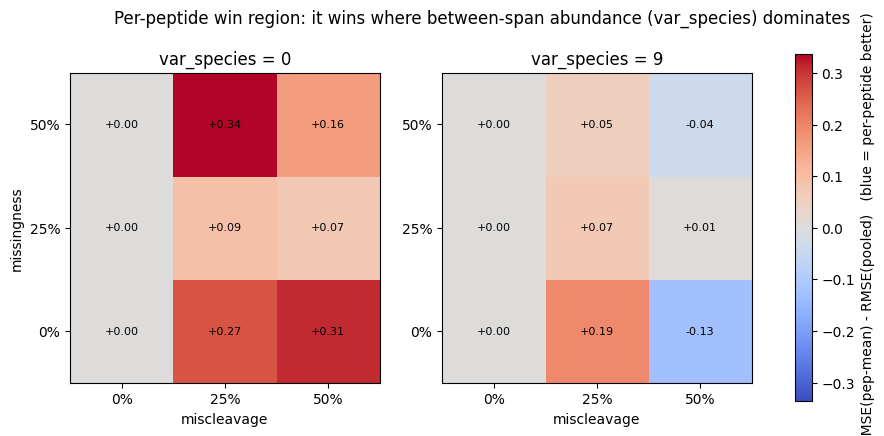

In [15]:
miss = [0.0, 0.25, 0.5]
mc = [0.0, 0.25, 0.5]
species = [0.0, 9.0]
c2_base = dict(n_proteins=5, protein_length=120, n_subjects=12, abundance=200,
               var_subject=1.0, var_site=1.0, position_aware=True)
c2 = run_sweep({"var_species": species, "missingness": miss, "miscleavage_rate": mc},
               {"pool": stoichiometry_method("fraction"), "pep": stoichiometry_method("peptide_mean")},
               n_replicates=3, base=c2_base)
mean = {(r.params["var_species"], r.params["missingness"], r.params["miscleavage_rate"], r.method): r.rmse_mean
        for r in c2}
diff = {sv: np.array([[mean[(sv, m, c, "pep")] - mean[(sv, m, c, "pool")] for c in mc] for m in miss])
        for sv in species}

vmax = max(np.abs(d).max() for d in diff.values())
fig, axes = plt.subplots(1, len(species), figsize=(11, 4.5), squeeze=False)
for k, sv in enumerate(species):
    ax = axes[0][k]
    im = ax.imshow(diff[sv], cmap="coolwarm", vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_xticks(range(len(mc)), [f"{c:.0%}" for c in mc])
    ax.set_yticks(range(len(miss)), [f"{m:.0%}" for m in miss])
    ax.set_xlabel("miscleavage")
    ax.set_title(f"var_species = {sv:g}")
    for i in range(len(miss)):
        for j in range(len(mc)):
            ax.text(j, i, f"{diff[sv][i, j]:+.2f}", ha="center", va="center", fontsize=8)
axes[0][0].set_ylabel("missingness")
fig.colorbar(im, ax=axes, label="RMSE(pep-mean) - RMSE(pooled)   (blue = per-peptide better)")
fig.suptitle("Per-peptide win region: it wins where between-span abundance (var_species) dominates")
plt.show()

**Within-span efficiency — decision.** No new model term is needed: the within-span mod-vs-unmod
efficiency difference is already captured by the per-site effect `var_site` (alpha_r), which shifts only
the modified peptides and so biases the modified fraction (numerator-only) — the one effect per-peptide
does *not* cancel (test `test_var_site_is_not_cancelled_by_per_peptide`). Per-peptide correctly cancels
`var_subject` (per-sample) and `var_species` (per-backbone) but stays exposed to `var_site`. A
*systematic* (non-zero-mean) mod efficiency would largely cancel in the between-group fold-change, so the
mean-0 alpha already models the variance that matters for RMSE.